# Component Tree Attribute as Image (a.k.a Attribute Maps)
Author : [Cyril Meyer](https://cyrilmeyer.eu/) (contact [at] cyrilmeyer [dot] eu) and Benjamin Perret.

## References
* [1] Meyer, C., Baudrier, É., Schultz, P., Naegel, B. (2023). Combining Max-Tree and CNN for Segmentation of Cellular FIB-SEM Images. In: Kerautret, B., Colom, M., Krähenbühl, A., Lopresti, D., Monasse, P., Perret, B. (eds) Reproducible Research in Pattern Recognition. RRPR 2022. Lecture Notes in Computer Science, vol 14068. Springer, Cham. https://doi.org/10.1007/978-3-031-40773-4_7
* [2] D. L. Farfan Cabrera, N. Gogin, D. Morland, B. Naegel, D. Papathanassiou and N. Passat, "Segmentation of Axillary and Supraclavicular Tumoral Lymph Nodes in PET/CT: A Hybrid CNN/Component-Tree Approach," 2020 25th International Conference on Pattern Recognition (ICPR), Milan, Italy, 2021, pp. 6672-6679. https://doi.org/10.1109/ICPR48806.2021.9412343
* [Cyril-Meyer/DGMM2022-RRPR-CTAISegmentationCNN](https://github.com/Cyril-Meyer/DGMM2022-RRPR-CTAISegmentationCNN)
* [Cyril-Meyer/LibTIM](https://github.com/Cyril-Meyer/libtim)


## Requirements

In [1]:
%%capture
!pip install higra

In [2]:
import higra as hg
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# DO NOT USE np.inf
inf = 1e100

## Toy example

In [4]:
img_toy = np.array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                    [0, 4, 3, 4, 0, 0, 0, 2, 2, 0],
                    [0, 2, 3, 3, 2, 1, 2, 2, 0, 0],
                    [0, 2, 4, 3, 2, 1, 0, 1, 0, 0],
                    [0, 0, 2, 0, 0, 0, 0, 0, 0, 0],
                    [0, 0, 0, 0, 3, 0, 4, 2, 0, 0],
                    [0, 1, 1, 0, 3, 2, 4, 4, 0, 0],
                    [0, 1, 1, 0, 3, 0, 4, 4, 1, 0],
                    [0, 1, 1, 0, 0, 0, 0, 1, 1, 0],
                    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], dtype=np.uint8)

100 (10, 10) [0 1 2 3 4]


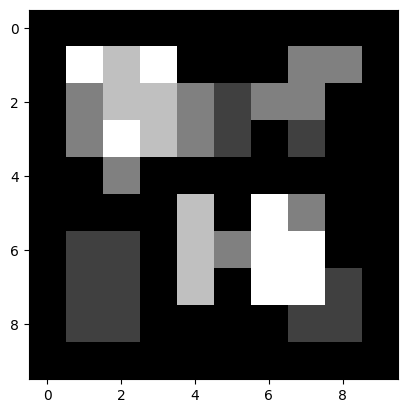

In [5]:
image = img_toy

print(image.size, image.shape, np.unique(image))
plt.imshow(image, cmap='gray')
plt.show()

In [6]:
g = hg.get_4_adjacency_implicit_graph(image.shape)
tree, altitudes = hg.component_tree_max_tree(g, vertex_weights=image)

### Area Map

In [7]:
area = hg.attribute_area(tree)
area_map = hg.reconstruct_leaf_data(tree, area)

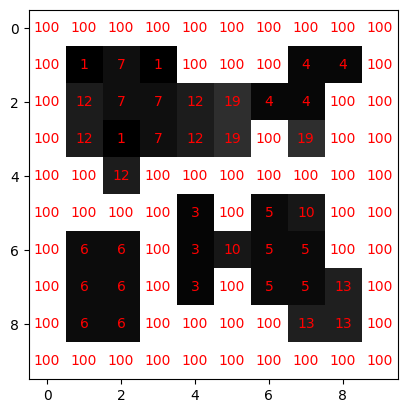

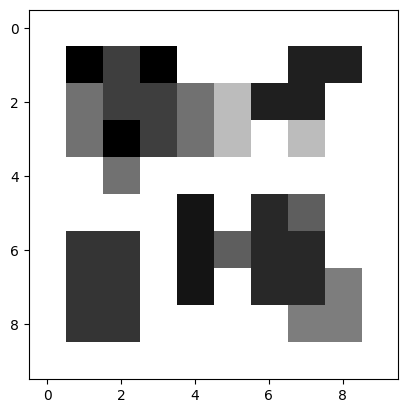

In [8]:
plt.imshow(area_map, cmap='gray')
for (j,i),label in np.ndenumerate(area_map):
  plt.text(i, j, int(label), ha='center', va='center', color='red')
plt.show()

plt.imshow(np.clip(area_map * 10, 0, 255), cmap='gray') # map * 10 to improve brightness
plt.show()

### Criterion $\nabla_A(N)$ and $\Delta_A(N)$ and Optimized Attribute Maps [1]

$\nabla_A(N) = \frac{\mid A(Par(N)) - A(N)\mid}{|H(Par(N))-H(N)|} \cdot \frac{1}{A(N)}$

$\Delta_A(N) = \nabla_A(Par(N)) - \nabla_A(N)$

In [9]:
nabla = np.full(altitudes.shape, -inf, dtype=np.float64)
delta = np.full(altitudes.shape, -inf, dtype=np.float64)

for n in tree.root_to_leaves_iterator(include_leaves=False, include_root=False):
    nabla[n] = (area[tree.parent(n)] - area[n]) / (altitudes[n] - altitudes[tree.parent(n)]) / (area[n])

for n in tree.root_to_leaves_iterator(include_leaves=False, include_root=False):
    delta[n] = nabla[tree.parent(n)] - nabla[n]

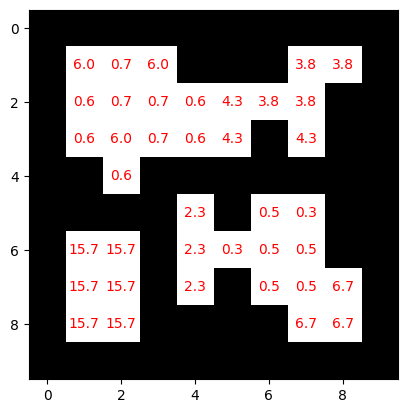

In [10]:
nabla_map = hg.reconstruct_leaf_data(tree, nabla)

plt.imshow(nabla_map, cmap='gray')
for (j,i),label in np.ndenumerate(nabla_map):
  label = '' if label == -inf else round(label,1)
  plt.text(i, j, label, ha='center', va='center', color='red')
plt.show()

In [11]:
def index_of_max_ancestor_vec(tree, attr):
  """
  for any node n, anc(n) denotes the set of ancestors of n (n is an ancestor of itself)
  res[n] = argmax_{p in anc(n)} attr(p)
  """
  # compute max attr value among ancestors
  max_anc = hg.propagate_sequential_and_accumulate(tree, attr, hg.Accumulators.max)
  # propagate the index of those nodes who where the max values
  ind_max_anc = hg.propagate_sequential(tree, np.arange(tree.num_vertices()), attr != max_anc)

  return ind_max_anc

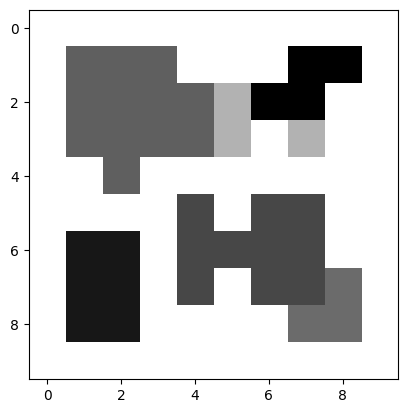

In [12]:
attribute = area
criterion = delta
ind_max_anc = index_of_max_ancestor_vec(tree, criterion)

area_map_optimized = hg.reconstruct_leaf_data(tree, attribute[ind_max_anc])

plt.imshow(np.clip(area_map_optimized * 10, 0, 255), cmap='gray') # map * 10 to improve brightness
plt.show()